In [2]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [3]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [6]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/4.goal_coding/")

# Single neurons firing rates show preference for different navigational goals at reward time

In [4]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [ ]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_trial_aligned(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(1, 0.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True, "smooth_SD": 15}, ax=ax2)

    f3, axes3 = plt.subplots(1, 2, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="event_aligned", feature_kwargs={"goal_stratified": True, "smooth_SD": 10}, ax=axes3)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f4, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        f1.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_inset.pdf")
        f2.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_trial_aligned_tuning.pdf")
        f3.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_event_aligned_tuning.pdf")
        f4.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_legend.pdf")
    else:
        return f1, f2, f3

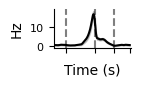

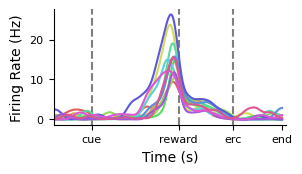

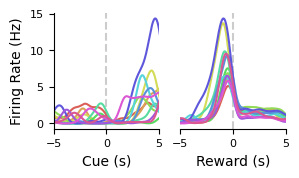

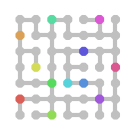

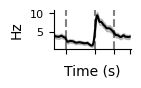

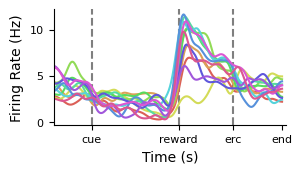

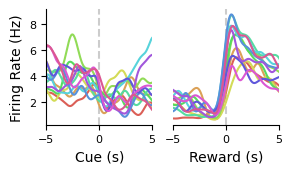

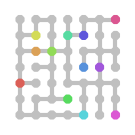

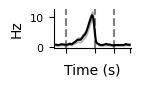

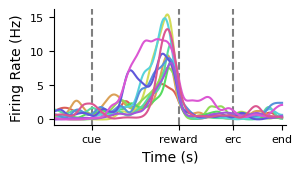

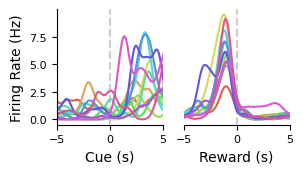

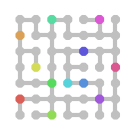

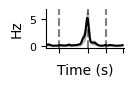

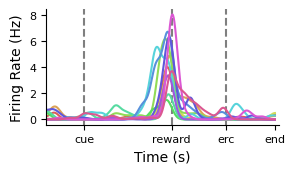

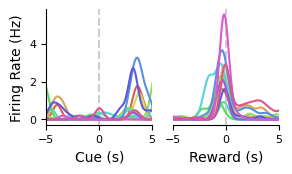

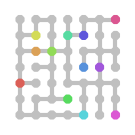

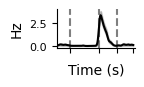

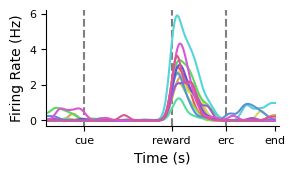

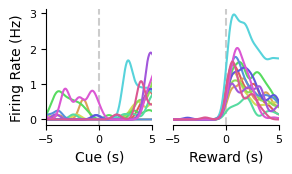

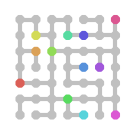

In [11]:
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster65", save_label="cluster_1")
plot_single_unit_trial_aligned("m3.2022-07-17.maze_cluster45", save_label="cluster_2")
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster114", save_label="cluster_3")
plot_single_unit_trial_aligned("m2.2022-07-17.maze_cluster50", save_label="cluster_4")
plot_single_unit_trial_aligned("m6.2022-07-05.maze_cluster134", save_label="cluster_5")

# start with simple logreg decoding aligned to trial events/ trial warped data

In [8]:
from GridMaze.analysis.goal_coding import simple_decoding as sd

In [9]:
event_aligned_df = sd.get_event_aligned_decoding_summary()
trial_aligned_df = sd.get_trial_aligned_decoding_summary()

Loading existing results from /ceph/behrens/peter_doohan/goalNav_mFC/experiment/results/simple_decoding/event_aligned_decoding_summary.parquet
Loading existing results from /ceph/behrens/peter_doohan/goalNav_mFC/experiment/results/simple_decoding/trial_aligned_decoding_summary.parquet


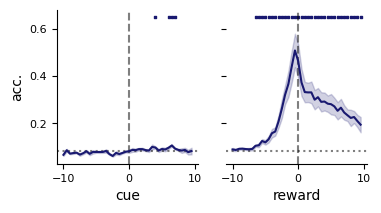

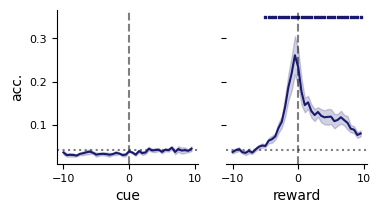

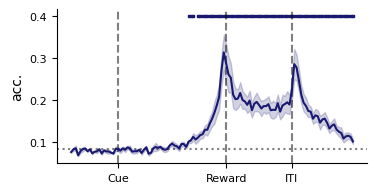

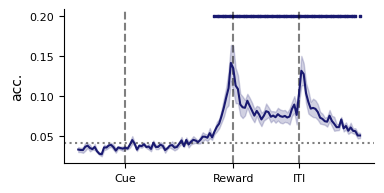

In [12]:
reload(sd)
f1, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    color="midnightblue",
    y_max=0.65,
    axes=axes,
)
f1.savefig(FIG_SAVE_PATH / "simple_decoding/event_aligned_subsets.pdf")
f2, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    color="midnightblue",
    y_max=0.35,
    axes=axes,
)
f2.savefig(FIG_SAVE_PATH / "simple_decoding/event_aligned_all.pdf")


f3, ax = plt.subplots(1, 1, figsize=(4, 2), clear=True)
sd.plot_trial_aligned_decoding(
    trial_aligned_df,
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    goal_subsets=["subset_1", "subset_2"],
    color="midnightblue",
    chance=1 / 12,
    y_max=0.4,
    ax=ax,
)
f3.savefig(FIG_SAVE_PATH / "simple_decoding/trial_aligned_subsets.pdf")


f4, ax = plt.subplots(1, 1, figsize=(4, 2), clear=True)
sd.plot_trial_aligned_decoding(
    trial_aligned_df,
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    goal_subsets=["all"],
    color="midnightblue",
    chance=1 / 24,
    y_max=0.2,
    ax=ax,
)
f4.savefig(FIG_SAVE_PATH / "simple_decoding/trial_aligned_all.pdf")

# No goal decoding at cue, when subjects are navigating to the goal ... 

In [13]:
from GridMaze.analysis.event_aligned import delta_distance_to_goal as ddg

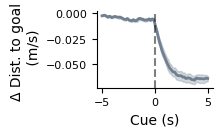

In [ ]:
# plot ddtg
f, ax = plt.subplots(1, 1, figsize=(1.5, 1), clear=True)
ddg.plot_cross_subject_rate_of_change_of_distance_to_goal(ax=ax, window_length=5, smooth_SD=6, color="slategrey")

# Is our goal decoding just general spatial coding?

In [15]:
from GridMaze.analysis.goal_coding import place_decoding_control as pdc

In [16]:
reload(pdc)
spatial_control_df = pdc.get_spatial_goal_decoding_control_summary()

Loading existing results from /ceph/behrens/peter_doohan/goalNav_mFC/experiment/results/goal_coding/place_decoding_control/spatial_control_goal_decoding_summary.parquet


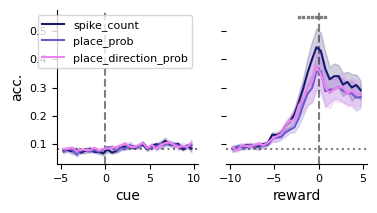

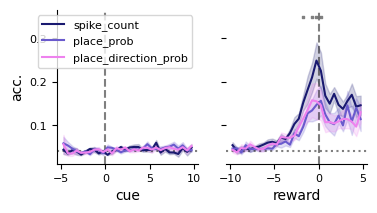

In [17]:
reload(pdc)
f1, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
pdc.plot_event_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    cue_window=(-5, 10),
    reward_window=(-10, 5),
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("midnightblue", "slateblue", "violet"),
    y_max=0.55,
    axes=axes,
)
f1.savefig(FIG_SAVE_PATH / "spatial_control/event_aligned_subsets.pdf")

f2, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
pdc.plot_event_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    cue_window=(-5, 10),
    reward_window=(-10, 5),
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("midnightblue", "slateblue", "violet"),
    y_max=0.35,
    axes=axes,
)
f2.savefig(FIG_SAVE_PATH / "spatial_control/event_aligned_all.pdf")

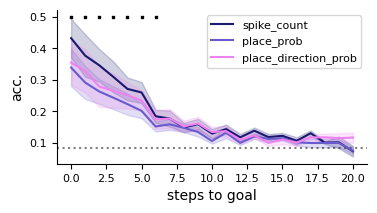

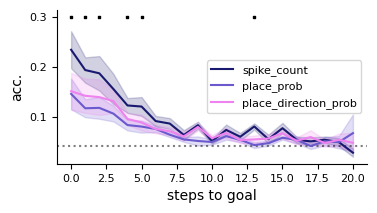

In [18]:
reload(pdc)
f, ax = plt.subplots(1, 1, figsize=(4, 2), sharey=True)
pdc.plot_distance_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    max_distance=20,
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("midnightblue", "slateblue", "violet"),
    residuals_comparison=["spike_count", "place_prob"],
    y_max=0.5,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "spatial_control/distance_aligned_subsets.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 2), sharey=True)
pdc.plot_distance_aligned_control_decoding(
    spatial_control_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["all"],
    chance=1 / 24,
    max_distance=20,
    plot_feature_sets=["spike_count", "place_prob", "place_direction_prob"],
    colors=("midnightblue", "slateblue", "violet"),
    residuals_comparison=["spike_count", "place_prob"],
    y_max=0.3,
    ax=ax,
)
f2.savefig(FIG_SAVE_PATH / "spatial_control/distance_aligned_all.pdf")

# are we data limited in our decoding?

In [20]:
from GridMaze.analysis.goal_coding import pseudo_trial_decoding as ptd

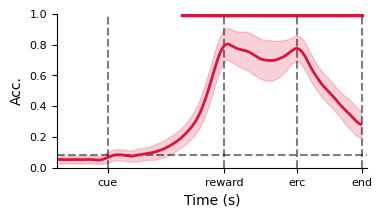

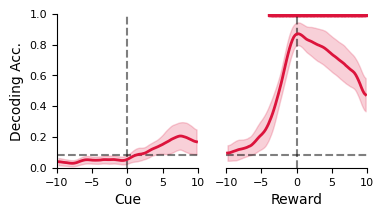

In [21]:
f, ax = plt.subplots(1, 1, figsize=(4, 2), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="trial",
    decoder="logreg",
    bootstrap_method="input",
    color="crimson",
    sig_color="crimson",
    sig_pos=1.0,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding/trial_aligned_linear.pdf")

f2, axes = plt.subplots(1, 2, figsize=(4, 2), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="event",
    decoder="logreg",
    bootstrap_method="input",
    color="crimson",
    sig_color="crimson",
    sig_pos=1.0,
    ax=axes,
)
f2.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding/event_aligned_linear.pdf")

# can we imporve performance with a more flexible decoder? 

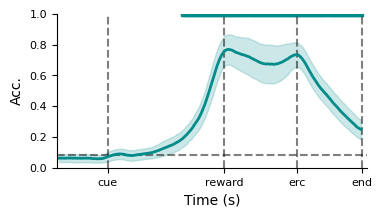

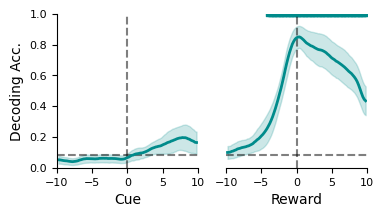

In [22]:
f, ax = plt.subplots(1, 1, figsize=(4, 2), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="trial",
    decoder="mlp_torch",
    bootstrap_method="input",
    color="darkcyan",
    sig_color="darkcyan",
    sig_pos=1.0,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding/trial_aligned_nonlinear.pdf")

f2, axes = plt.subplots(1, 2, figsize=(4, 2), clear=True)
ptd.plot_goal_decoding(
    datasets=[("maze_1", "subset_1"), ("maze_1", "subset_2"), ("maze_2", "subset_1"), ("maze_2", "subset_2")],
    alignment="event",
    decoder="mlp_torch",
    bootstrap_method="input",
    color="darkcyan",
    sig_color="darkcyan",
    sig_pos=1.0,
    ax=axes,
)
f2.savefig(FIG_SAVE_PATH / "pseudo_trial_decoding/event_aligned_nonlinear.pdf")

# Extra: reward time repsentations change with maze strucutre

T-statistic: 8.1789
P-value: 0.0004
Degrees of freedom: 5


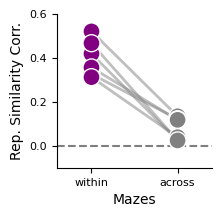

In [23]:
# Load data
from GridMaze.analysis.event_aligned import reward_time_reps as rtr

RSM_comparisons_df = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="event",
    window=(-0.25, 0.25),
)
# show stats
rtr.plot_RDM_comparisons(RSM_comparisons_df, print_stats=True)

T-statistic: 3.9835
P-value: 0.0105
Degrees of freedom: 5


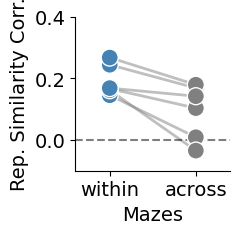

In [48]:
# plot locomotion controlled version of reward rep sim analysis
reload(rtr)
RSM_comparisons_df2 = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="trial",
    window=(0, 1),
)
rtr.plot_RDM_comparisons(RSM_comparisons_df2, color="steelblue", print_stats=True, ymax=0.4)

# enlarged plots for main figure

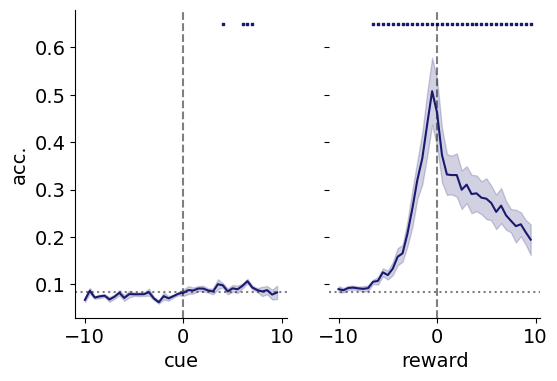

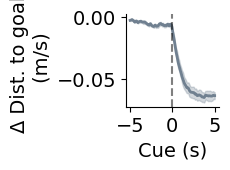

In [ ]:
f1, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
sd.plot_event_aligned_decoding(
    event_aligned_df,
    maze_names=["maze_1", "maze_2"],
    goal_subsets=["subset_1", "subset_2"],
    chance=1 / 12,
    color="midnightblue",
    y_max=0.65,
    axes=axes,
)
f1.savefig(FIG_SAVE_PATH / "event_aligned_decoding_large.pdf")
f2, ax = plt.subplots(1, 1, figsize=(1.2, 1.2), clear=True)
ddg.plot_cross_subject_rate_of_change_of_distance_to_goal(ax=ax, window_length=5, smooth_SD=6, color="slategrey")
f2.savefig(FIG_SAVE_PATH / "rate_of_change_of_distance_to_goal_large.pdf")